In [1]:
from getpass import getuser # Libaray to copy things
from pathlib import Path # Object oriented libary to deal with paths
import os
from tempfile import NamedTemporaryFile, TemporaryDirectory # Creating temporary Files/Dirs
from subprocess import run, PIPE
import sys
 
import dask # Distributed data libary
from dask_jobqueue import SLURMCluster # Setting up distributed memories via slurm
from distributed import Client, progress, wait # Libaray to orchestrate distributed resources
import xarray as xr # Libary to work with labeled n-dimensional data and dask

In [2]:
# Set some user specific variables
scratch_dir = Path('/scratch') / getuser()[0] / getuser() # Define the users scratch dir
# Create a temp directory where the output of distributed cluster will be written to, after this notebook
# is closed the temp directory will be closed
dask_tmp_dir = TemporaryDirectory(dir=scratch_dir, prefix='PostProc')
cluster = SLURMCluster(memory='400GiB',
                       cores=72,
                       project='mh0731',
                       walltime='1:00:00',
                       queue='compute',
                       name='PostProc',
                   #    scheduler_options={'dashboard_address': ':12435'},
                       local_directory=dask_tmp_dir.name,
                       job_extra=[f'-J PostProc', 
                                  f'-D {dask_tmp_dir.name}',
                                  f'--begin=now',
                                  f'--output={dask_tmp_dir.name}/LOG_cluster.%j.o',
                                  f'--output={dask_tmp_dir.name}/LOG_cluster.%j.o'
                                 ],
                       interface='ib0')
cluster.scale(jobs=1)
dask_client = Client(cluster)

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/dask_jobqueue/core.py:255: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/dask_jobqueue/slurm.py:49: FutureWarning: project has been renamed to account as this kwarg was used wit -A option. You are still using it (please also check config files). If you did not set account yet, project will be respected for now, but it will be removed in a future release. If you already set account, project is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/sw/spack-le

In [3]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

# calculation
import metpy.calc as mpcalc

# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# basic
from pathlib import Path # Object oriented libary to deal with paths
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data
import glob

## 1) Calculate 6n+1 and wa, prw

In [4]:
import xarray as xr
import numpy as np
import glob
import pandas as pd

# Define the path and file name pattern
data_path_pr_ctl = '/scratch/m/m300948/test_04/pr/'
data_path_prw_ctl = '/scratch/m/m300948/test_04/prw/'
data_path_wa_ctl = '/scratch/m/m300948/test_04/3d/vertical_w/6hourly/'

file_pattern_pr_prw = 'ctl_daily_{}_2022{:02d}*.nc'
file_pattern_wa = 'ctl_daily_wa_plev_2022{:02d}*.nc'

# Define latitude and longitude range
lat_start = -17
lat_end = 9
lon_start = -80
lon_end = -45

# Initialize lists to accumulate data
W_ctl_list = []
TCW_ctl_list = []
Precip_ctl_list = []

# Loop over each month
for i in range(1, 13):
    # Use glob to find all files matching the pattern
    pr_files = glob.glob(data_path_pr_ctl + file_pattern_pr_prw.format('pr', i))
    prw_files = glob.glob(data_path_prw_ctl + file_pattern_pr_prw.format('prw', i))
    wa_files = glob.glob(data_path_wa_ctl + file_pattern_wa.format(i))

    # Load datasets
    pr_ctl = xr.open_mfdataset(pr_files, chunks={'time': 1, 'lat': -1, 'lon': -1})['pr'] 
    prw_ctl = xr.open_mfdataset(prw_files, chunks={'time': 1, 'lat': -1, 'lon': -1})['prw']
    wa_ctl = xr.open_mfdataset(wa_files, chunks={'time': 1, 'plev': -1, 'lat': -1, 'lon': -1})['wa']

    # Load the biome mask
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES
    ABinterp_biome_ctl = AMZ_BD.interp(latitude=pr_ctl.lat, longitude=pr_ctl.lon)
    pr_ctl_mask = pr_ctl.where(ABinterp_biome_ctl == 0, np.nan)
    prw_ctl_mask = prw_ctl.where(ABinterp_biome_ctl == 0, np.nan)
    wa_ctl_mask = wa_ctl.sel(plev=50000).where(ABinterp_biome_ctl == 0, np.nan)

    # Select latitude and longitude range
    pr_ctl_sel = pr_ctl_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
    prw_ctl_sel = prw_ctl_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
    wa_ctl_sel = wa_ctl_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
    
    # Mask one hour before the 6n+1-hourly data
    ctl_mask = (pr_ctl_sel.time.dt.hour % 6 == 1) & (pr_ctl_sel*3600 > 50) # 6n+1 에 맞춰서 True false
    pr_ctl_mask_sel = pr_ctl_sel.where(pr_ctl_sel['time'].dt.minute == 0, drop=True).where(ctl_mask) * 3600 # Remove the minute dimension and apply mask
    # Extract only the desired hours (1, 7, 13, 19)
    hours = pr_ctl_mask_sel['time'].dt.hour
    desired_hours = [1, 7, 13, 19]
    pr_ctl_mask_sel_6plus1 = pr_ctl_mask_sel.sel(time=hours.isin(desired_hours))
    
    # Change the time index to 6-hourly, 00:00, 06:00, 12:00, 18:00
    new_time = pd.date_range(start=pr_ctl_mask_sel_6plus1.time.values[0] - pd.Timedelta(hours=1), 
                            periods=len(pr_ctl_mask_sel_6plus1.time), 
                            freq='6H')
    # Assign the new time index to the dataset
    pr_ctl_mask_sel_6plus1['time'] = new_time
    
    # Mask the other datasets
    common_time = pr_ctl_mask_sel_6plus1.time.to_index().intersection(prw_ctl_sel.time.to_index()).intersection(wa_ctl_sel.time.to_index())
    pr_ctl_sel_6plus1_common = pr_ctl_mask_sel_6plus1.sel(time=common_time)
    prw_ctl_sel_common = prw_ctl_sel.sel(time=common_time)
    wa_ctl_sel_common = wa_ctl_sel.sel(time=common_time)
    
    mask = ~np.isnan(pr_ctl_sel_6plus1_common)
    prw_def_sel_common_mask = prw_ctl_sel_common.where(mask)
    wa_ctl_sel_common_mask = wa_ctl_sel_common.where(mask)
    
    # Flatten and accumulate data
    W_ctl_flat = wa_ctl_sel_common.values.flatten()
    TCW_ctl_flat = prw_ctl_sel_common.values.flatten()
    Precip_ctl_flat = pr_ctl_sel_6plus1_common.values.flatten() 

    W_ctl_list.append(W_ctl_flat)
    TCW_ctl_list.append(TCW_ctl_flat)
    Precip_ctl_list.append(Precip_ctl_flat)

W_ctl_all = np.concatenate(W_ctl_list)
TCW_ctl_all = np.concatenate(TCW_ctl_list)
Precip_ctl_all = np.concatenate(Precip_ctl_list)

In [5]:
import xarray as xr
import numpy as np
import glob
import pandas as pd

# Define the path and file name pattern
data_path_pr_def = '/scratch/m/m300948/def_100/pr/'
data_path_prw_def = '/scratch/m/m300948/def_100/prw/'
data_path_wa_def = '/scratch/m/m300948/def_100/3d/vertical_w/6hourly/'

file_pattern_pr_prw = 'def_daily_{}_2022{:02d}*.nc'
file_pattern_wa = 'def_daily_wa_plev_2022{:02d}*.nc'

# Define latitude and longitude range
lat_start = -17
lat_end = 9
lon_start = -80
lon_end = -45

# Initialize lists to accumulate data
W_def_list = []
TCW_def_list = []
Precip_def_list = []

# Loop over each month
for i in range(1, 13):
    # Use glob to find all files matching the pattern
    pr_files = glob.glob(data_path_pr_def + file_pattern_pr_prw.format('pr', i))
    prw_files = glob.glob(data_path_prw_def + file_pattern_pr_prw.format('prw', i))
    wa_files = glob.glob(data_path_wa_def + file_pattern_wa.format(i))

    # Load datasets
    pr_def = xr.open_mfdataset(pr_files, chunks={'time': 1, 'lat': -1, 'lon': -1})['pr'] 
    prw_def = xr.open_mfdataset(prw_files, chunks={'time': 1, 'lat': -1, 'lon': -1})['prw']
    wa_def = xr.open_mfdataset(wa_files, chunks={'time': 1, 'plev': -1, 'lat': -1, 'lon': -1})['wa']

    # Load the biome mask
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES
    ABinterp_biome_def = AMZ_BD.interp(latitude=pr_def.lat, longitude=pr_def.lon)
    pr_def_mask = pr_def.where(ABinterp_biome_def == 0, np.nan)
    prw_def_mask = prw_def.where(ABinterp_biome_def == 0, np.nan)
    wa_def_mask = wa_def.sel(plev=50000).where(ABinterp_biome_def == 0, np.nan)

    # Select latitude and longitude range
    pr_def_sel = pr_def_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
    prw_def_sel = prw_def_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
    wa_def_sel = wa_def_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
    
    # Mask one hour before the 6n+1-hourly data
    def_mask = (pr_def_sel.time.dt.hour % 6 == 1) & (pr_def_sel*3600 > 50) # 6n+1 에 맞춰서 True false
    pr_def_mask_sel = pr_def_sel.where(pr_def_sel['time'].dt.minute == 0, drop=True).where(def_mask) * 3600 # Remove the minute dimension and apply mask
    # Extract only the desired hours (1, 7, 13, 19)
    hours = pr_def_mask_sel['time'].dt.hour
    desired_hours = [1, 7, 13, 19]
    pr_def_mask_sel_6plus1 = pr_def_mask_sel.sel(time=hours.isin(desired_hours))
    
    # Change the time index to 6-hourly, 00:00, 06:00, 12:00, 18:00
    new_time = pd.date_range(start=pr_def_mask_sel_6plus1.time.values[0] - pd.Timedelta(hours=1), 
                            periods=len(pr_def_mask_sel_6plus1.time), 
                            freq='6H')
    # Assign the new time index to the dataset
    pr_def_mask_sel_6plus1['time'] = new_time
    
    # Mask the other datasets
    common_time = pr_def_mask_sel_6plus1.time.to_index().intersection(prw_def_sel.time.to_index()).intersection(wa_def_sel.time.to_index())
    pr_def_sel_6plus1_common = pr_def_mask_sel_6plus1.sel(time=common_time)
    prw_def_sel_common = prw_def_sel.sel(time=common_time)
    wa_def_sel_common = wa_def_sel.sel(time=common_time)
    
    mask = ~np.isnan(pr_def_sel_6plus1_common)
    prw_def_sel_common_mask = prw_def_sel_common.where(mask)
    wa_def_sel_common_mask = wa_def_sel_common.where(mask)
    
    # Flatten and accumulate data
    W_def_flat = wa_ctl_sel_common_mask.values.flatten()
    TCW_def_flat = prw_def_sel_common_mask.values.flatten()
    Precip_def_flat = pr_def_sel_6plus1_common.values.flatten() 

    W_def_list.append(W_def_flat)
    TCW_def_list.append(TCW_def_flat)
    Precip_def_list.append(Precip_def_flat)

W_def_all = np.concatenate(W_def_list)
TCW_def_all = np.concatenate(TCW_def_list)
Precip_def_all = np.concatenate(Precip_def_list)

## Figure2

In [9]:
import xarray as xr
import numpy as np
import glob
import pandas as pd

# Define the path and file name pattern
data_path_pr_ctl = '/scratch/m/m300948/test_04/pr/'
data_path_prw_ctl = '/scratch/m/m300948/test_04/prw/'
data_path_wa_ctl = '/scratch/m/m300948/test_04/3d/vertical_w/6hourly/'

file_pattern_pr_prw = 'ctl_daily_{}_2022{:02d}*.nc'
file_pattern_wa = 'ctl_daily_wa_plev_2022{:02d}*.nc'

# Define latitude and longitude range
lat_start = -17
lat_end = 9
lon_start = -80
lon_end = -45

# Initialize lists to accumulate data
W_ctl_list = []
TCW_ctl_list = []
Precip_ctl_list = []

# Loop over each month
for i in range(1, 13):
    # Use glob to find all files matching the pattern
    pr_files = glob.glob(data_path_pr_ctl + file_pattern_pr_prw.format('pr', i))
    prw_files = glob.glob(data_path_prw_ctl + file_pattern_pr_prw.format('prw', i))
    wa_files = glob.glob(data_path_wa_ctl + file_pattern_wa.format(i))

    # Load datasets
    pr_ctl = xr.open_mfdataset(pr_files, chunks={'time': 1, 'lat': -1, 'lon': -1})['pr'] 
    prw_ctl = xr.open_mfdataset(prw_files, chunks={'time': 1, 'lat': -1, 'lon': -1})['prw']
    wa_ctl = xr.open_mfdataset(wa_files, chunks={'time': 1, 'plev': -1, 'lat': -1, 'lon': -1})['wa']

    # Load the biome mask
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES
    ABinterp_biome_ctl = AMZ_BD.interp(latitude=pr_ctl.lat, longitude=pr_ctl.lon)
    pr_ctl_mask = pr_ctl.where(ABinterp_biome_ctl == 0, np.nan)
    prw_ctl_mask = prw_ctl.where(ABinterp_biome_ctl == 0, np.nan)
    wa_ctl_mask = wa_ctl.sel(plev=50000).where(ABinterp_biome_ctl == 0, np.nan)

    # Select latitude and longitude range
    pr_ctl_sel = pr_ctl_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
    prw_ctl_sel = prw_ctl_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
    wa_ctl_sel = wa_ctl_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
    
    # Mask one hour before the 6n+1-hourly data
    ctl_mask = (pr_ctl_sel.time.dt.hour % 6 == 0) & (pr_ctl_sel*3600 > 50) # 6n+1 에 맞춰서 True false
    pr_ctl_mask_sel = pr_ctl_sel.where(pr_ctl_sel['time'].dt.minute == 0, drop=True).where(ctl_mask) * 3600 # Remove the minute dimension and apply mask
    # Extract only the desired hours (1, 7, 13, 19)
    hours = pr_ctl_mask_sel['time'].dt.hour
    desired_hours = [0, 6, 12, 18]
    pr_ctl_mask_sel_6plus1 = pr_ctl_mask_sel.sel(time=hours.isin(desired_hours))
    
    # Mask the other datasets
    common_time = pr_ctl_mask_sel_6plus1.time.to_index().intersection(prw_ctl_sel.time.to_index()).intersection(wa_ctl_sel.time.to_index())
    pr_ctl_sel_6plus1_common = pr_ctl_mask_sel_6plus1.sel(time=common_time)
    prw_ctl_sel_common = prw_ctl_sel.sel(time=common_time)
    wa_ctl_sel_common = wa_ctl_sel.sel(time=common_time)
    
    mask = ~np.isnan(pr_ctl_sel_6plus1_common)
    prw_ctl_sel_common_mask = prw_ctl_sel_common.where(mask)
    wa_ctl_sel_common_mask = wa_ctl_sel_common.where(mask)
    
    # Flatten and accumulate data
    W_ctl_flat = wa_ctl_sel_common.values.flatten()
    TCW_ctl_flat = prw_ctl_sel_common.values.flatten()
    Precip_ctl_flat = pr_ctl_sel_6plus1_common.values.flatten() 

    W_ctl_list.append(W_ctl_flat)
    TCW_ctl_list.append(TCW_ctl_flat)
    Precip_ctl_list.append(Precip_ctl_flat)

W_ctl_all = np.concatenate(W_ctl_list)
TCW_ctl_all = np.concatenate(TCW_ctl_list)
Precip_ctl_all = np.concatenate(Precip_ctl_list)

In [10]:
import xarray as xr
import numpy as np
import glob
import pandas as pd

# Define the path and file name pattern
data_path_pr_def = '/scratch/m/m300948/def_100/pr/'
data_path_prw_def = '/scratch/m/m300948/def_100/prw/'
data_path_wa_def = '/scratch/m/m300948/def_100/3d/vertical_w/6hourly/'

file_pattern_pr_prw = 'def_daily_{}_2022{:02d}*.nc'
file_pattern_wa = 'def_daily_wa_plev_2022{:02d}*.nc'

# Define latitude and longitude range
lat_start = -17
lat_end = 9
lon_start = -80
lon_end = -45

# Initialize lists to accumulate data
W_def_list = []
TCW_def_list = []
Precip_def_list = []

# Loop over each month
for i in range(1, 13):
    # Use glob to find all files matching the pattern
    pr_files = glob.glob(data_path_pr_def + file_pattern_pr_prw.format('pr', i))
    prw_files = glob.glob(data_path_prw_def + file_pattern_pr_prw.format('prw', i))
    wa_files = glob.glob(data_path_wa_def + file_pattern_wa.format(i))

    # Load datasets
    pr_def = xr.open_mfdataset(pr_files, chunks={'time': 1, 'lat': -1, 'lon': -1})['pr'] 
    prw_def = xr.open_mfdataset(prw_files, chunks={'time': 1, 'lat': -1, 'lon': -1})['prw']
    wa_def = xr.open_mfdataset(wa_files, chunks={'time': 1, 'plev': -1, 'lat': -1, 'lon': -1})['wa']

    # Load the biome mask
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES
    ABinterp_biome_def = AMZ_BD.interp(latitude=pr_def.lat, longitude=pr_def.lon)
    pr_def_mask = pr_def.where(ABinterp_biome_def == 0, np.nan)
    prw_def_mask = prw_def.where(ABinterp_biome_def == 0, np.nan)
    wa_def_mask = wa_def.sel(plev=50000).where(ABinterp_biome_def == 0, np.nan)

    # Select latitude and longitude range
    pr_def_sel = pr_def_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
    prw_def_sel = prw_def_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
    wa_def_sel = wa_def_mask.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
    
    # Mask one hour before the 6n+1-hourly data
    def_mask = (pr_def_sel.time.dt.hour % 6 == 0) & (pr_def_sel*3600 > 50) # 6n+1 에 맞춰서 True false
    pr_def_mask_sel = pr_def_sel.where(pr_def_sel['time'].dt.minute == 0, drop=True).where(def_mask) * 3600 # Remove the minute dimension and apply mask
    # Extract only the desired hours (1, 7, 13, 19)
    hours = pr_def_mask_sel['time'].dt.hour
    desired_hours = [0, 6, 12, 18]
    pr_def_mask_sel_6plus1 = pr_def_mask_sel.sel(time=hours.isin(desired_hours))
    
    # Mask the other datasets
    common_time = pr_def_mask_sel_6plus1.time.to_index().intersection(prw_def_sel.time.to_index()).intersection(wa_def_sel.time.to_index())
    pr_def_sel_6plus1_common = pr_def_mask_sel_6plus1.sel(time=common_time)
    prw_def_sel_common = prw_def_sel.sel(time=common_time)
    wa_def_sel_common = wa_def_sel.sel(time=common_time)
    
    mask = ~np.isnan(pr_def_sel_6plus1_common)
    prw_def_sel_common_mask = prw_def_sel_common.where(mask)
    wa_def_sel_common_mask = wa_def_sel_common.where(mask)
    
    # Flatten and accumulate data
    W_def_flat = wa_def_sel_common.values.flatten()
    TCW_def_flat = prw_def_sel_common.values.flatten()
    Precip_def_flat = pr_def_sel_6plus1_common.values.flatten() 

    W_def_list.append(W_def_flat)
    TCW_def_list.append(TCW_def_flat)
    Precip_def_list.append(Precip_def_flat)

W_def_all = np.concatenate(W_def_list)
TCW_def_all = np.concatenate(TCW_def_list)
Precip_def_all = np.concatenate(Precip_def_list)

/tmp/ipykernel_2692938/3867185531.py:20: RuntimeWarning: invalid value encountered in divide
  avg_precip = precip_2d / counts


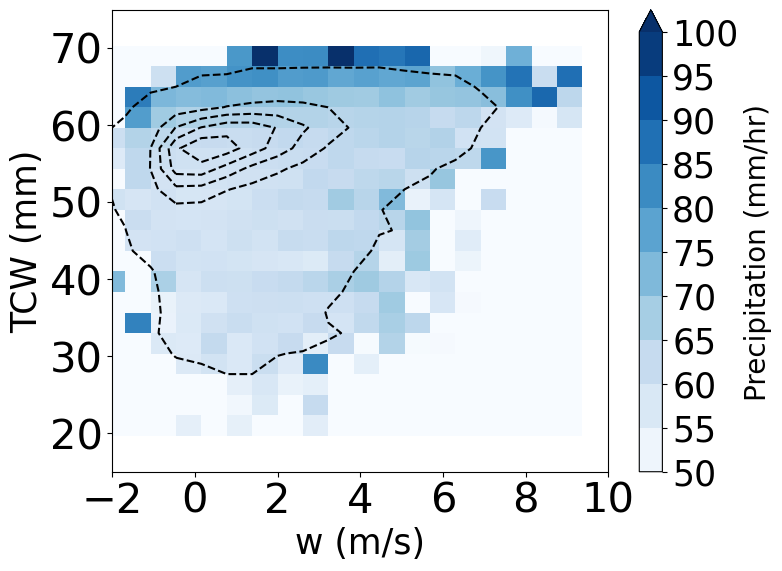

In [11]:
# Step 2: Mask to remove any NaN values in any of the three datasets
mask = ~np.isnan(W_ctl_all) & ~np.isnan(TCW_ctl_all) & ~np.isnan(Precip_ctl_all)

W_clean = W_ctl_all[mask]
TCW_clean = TCW_ctl_all[mask]
Precip_clean = Precip_ctl_all[mask]

# Step 3: Create 2D histogram binning the TCW and W, using precipitation as color
# ctline number of bins for x and y (TCW and W)
x_bins = np.linspace(np.nanmin(W_clean), np.nanmax(W_clean), 20)  # Adjust bin size if needed
y_bins = np.linspace(np.nanmin(TCW_clean), np.nanmax(TCW_clean), 20)

# Create 2D histogram for binned precipitation data
precip_2d, x_edges, y_edges = np.histogram2d(W_clean, TCW_clean, bins=[x_bins, y_bins], weights=Precip_clean)

# Count the number of data points in each bin (to avoid dividing by zero)
counts, _, _ = np.histogram2d(W_clean, TCW_clean, bins=[x_bins, y_bins])

# Avoid division by zero by replacing zeros in counts with NaNs
avg_precip = precip_2d / counts
avg_precip[np.isnan(avg_precip)] = 0  # Replace NaNs with 0 if needed
#avg_precip[avg_precip < 50] = np.nan

# Step 4: Plot using pcolormesh
plt.figure(figsize=(8, 6))

# Plot the 2D grid with colors representing precipitation
plt.pcolormesh(x_edges, y_edges, avg_precip.T, shading='auto', cmap='Blues', vmin=50, vmax=100)
bounds = np.linspace(50, 100, 11)
cbar = plt.colorbar(extend='max', ticks=bounds, boundaries=bounds)
cbar.ax.tick_params(labelsize=25)
cbar.set_label('Precipitation (mm/hr)', fontsize=20)

# Set custom contour levels
custom_contour_levels = np.linspace(10, 2000, 5)  # Define your desired contour levels

# Plot contour lines for the counts (frequency of W and TCW)
plt.contour(x_edges[:-1], y_edges[:-1], counts.T, levels=custom_contour_levels, colors='black', linewidths=1.5, linestyles='--')

# Set axis labels
plt.xlabel('w (m/s)', fontsize=25)
plt.ylabel('TCW (mm)', fontsize=25)
#plt.title('Precipitation Based on U600-U925 and TCW', fontsize=14)
plt.ylim(15, 75)
plt.xlim(-2, 10)

plt.xticks(fontsize=30)
plt.yticks(fontsize=30)

plt.show()

/tmp/ipykernel_2692938/1688773652.py:20: RuntimeWarning: invalid value encountered in divide
  avg_precip = precip_2d / counts


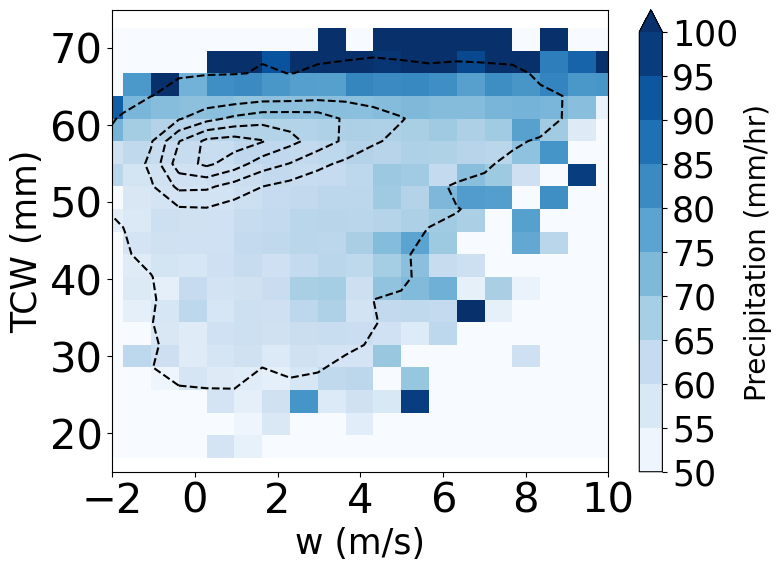

In [12]:
# Step 2: Mask to remove any NaN values in any of the three datasets
mask = ~np.isnan(W_def_all) & ~np.isnan(TCW_def_all) & ~np.isnan(Precip_def_all)

W_clean = W_def_all[mask]
TCW_clean = TCW_def_all[mask]
Precip_clean = Precip_def_all[mask]

# Step 3: Create 2D histogram binning the TCW and W, using precipitation as color
# define number of bins for x and y (TCW and W)
x_bins = np.linspace(np.nanmin(W_clean), np.nanmax(W_clean), 20)  # Adjust bin size if needed
y_bins = np.linspace(np.nanmin(TCW_clean), np.nanmax(TCW_clean), 20)

# Create 2D histogram for binned precipitation data
precip_2d, x_edges, y_edges = np.histogram2d(W_clean, TCW_clean, bins=[x_bins, y_bins], weights=Precip_clean)

# Count the number of data points in each bin (to avoid dividing by zero)
counts, _, _ = np.histogram2d(W_clean, TCW_clean, bins=[x_bins, y_bins])

# Avoid division by zero by replacing zeros in counts with NaNs
avg_precip = precip_2d / counts
avg_precip[np.isnan(avg_precip)] = 0  # Replace NaNs with 0 if needed
#avg_precip[avg_precip < 50] = np.nan

# Step 4: Plot using pcolormesh
plt.figure(figsize=(8, 6))

# Plot the 2D grid with colors representing precipitation
plt.pcolormesh(x_edges, y_edges, avg_precip.T, shading='auto', cmap='Blues', vmin=50, vmax=100)
bounds = np.linspace(50, 100, 11)
cbar = plt.colorbar(extend='max', ticks=bounds, boundaries=bounds)
cbar.ax.tick_params(labelsize=25)
cbar.set_label('Precipitation (mm/hr)', fontsize=20)

# Set custom contour levels
custom_contour_levels = np.linspace(10, 2000, 5)  # Define your desired contour levels

# Plot contour lines for the counts (frequency of W and TCW)
plt.contour(x_edges[:-1], y_edges[:-1], counts.T, levels=custom_contour_levels, colors='black', linewidths=1.5, linestyles='--')

# Set axis labels
plt.xlabel('w (m/s)', fontsize=25)
plt.ylabel('TCW (mm)', fontsize=25)
#plt.title('Precipitation Based on U600-U925 and TCW', fontsize=14)
plt.ylim(15, 75)
plt.xlim(-2, 10)

plt.xticks(fontsize=30)
plt.yticks(fontsize=30)

plt.show()

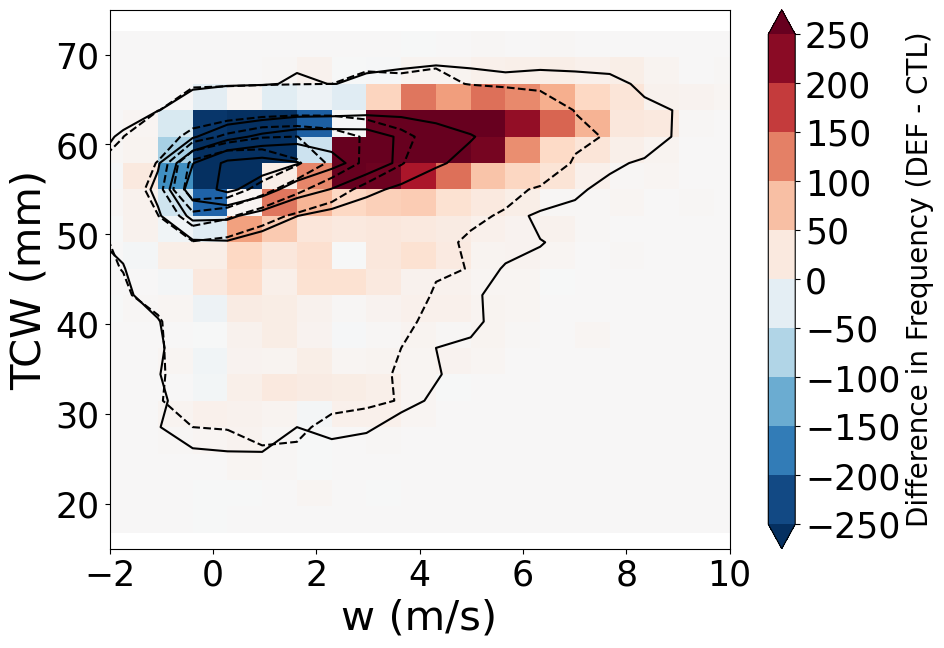

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Mask to remove any NaN values in any of the three datasets
mask_ctl = ~np.isnan(W_ctl_all) & ~np.isnan(TCW_ctl_all) & ~np.isnan(Precip_ctl_all)
mask_def = ~np.isnan(W_def_all) & ~np.isnan(TCW_def_all) & ~np.isnan(Precip_def_all)

U_diff_clean_ctl = W_ctl_all[mask_ctl]
TCW_clean_ctl = TCW_ctl_all[mask_ctl]
Precip_clean_ctl = Precip_ctl_all[mask_ctl]

U_diff_clean_def = W_def_all[mask_def]
TCW_clean_def = TCW_def_all[mask_def]
Precip_clean_def = Precip_def_all[mask_def]

# Step 3: Create a 2D histogram binning the TCW and U_diff, based on event frequency
x_bins = np.linspace(np.nanmin(U_diff_clean_def), np.nanmax(U_diff_clean_def), 20)
y_bins = np.linspace(np.nanmin(TCW_clean_def), np.nanmax(TCW_clean_def), 20)

# Create 2D histograms counting the number of events in each bin
counts_ctl, x_edges_ctl, y_edges_ctl = np.histogram2d(U_diff_clean_ctl, TCW_clean_ctl, bins=[x_bins, y_bins])
counts_def, x_edges_def, y_edges_def = np.histogram2d(U_diff_clean_def, TCW_clean_def, bins=[x_bins, y_bins])

# Calculate the difference between DEF and CTL
counts_diff = counts_def - counts_ctl

# Step 4: Plot the difference using a diverging color map (RdBu)
plt.figure(figsize=(10, 7))

# Plot the difference between DEF and CTL
m = plt.pcolormesh(x_edges_ctl, y_edges_ctl, counts_diff.T, shading='auto', cmap='RdBu_r', vmin=-250, vmax=250 ) #vmin=-np.max(np.abs(counts_diff)), vmax=np.max(np.abs(counts_diff)))

# Optional: Overlay contours for CTL to provide reference points
plt.contour(x_edges_ctl[:-1], y_edges_ctl[:-1], counts_ctl.T, levels=np.linspace(10, 2000, 5), colors='black', linewidths=1.5, linestyles='--')
plt.contour(x_edges_def[:-1], y_edges_def[:-1], counts_def.T, levels=np.linspace(10, 2000, 5), colors='black', linewidths=1.5, linestyles='-')

# Add a colorbar for the difference plot
# Add colorbar for precipitation
bounds = np.linspace(-250, 250, 11)
cbar = plt.colorbar(m, extend='both', ticks=bounds, boundaries=bounds)
cbar.ax.tick_params(labelsize=25)
cbar.set_label('Difference in Frequency (DEF - CTL)', fontsize=20)

# Set axis labels
plt.xlabel('w (m/s)', fontsize=30)
plt.ylabel('TCW (mm)', fontsize=30)
plt.ylim(15, 75)
plt.xlim(-2, 10)
# Set tick size for the plot
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

plt.show()
